# Phase 5: EDA, Statistics and Visualisation
## London Airbnb Analysis - Mohan Raju Kolikonda

Exploratory analysis answering the charter's business questions, with a hypothesis test and correlation analysis informing ML feature seclection in Phase 6.

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

listings = pd.read_csv('../data/listings_clean.csv',parse_dates=['first_review', 'last_review'])
reviews_monthly = pd.read_csv('../data/reviews_monthly.csv')

print("Listings:", listings.shape)
print("Reviews monthly:", reviews_monthly.shape)

Listings: (92638, 31)
Reviews monthly: (900540, 3)


"## Descriptive statistics for numeric columns"

In [2]:
numeric_cols = ['price', 'price_per_person', 'accommodates', 'bathrooms',
                'minimum_nights', 'availability_365', 'number_of_reviews',
                'reviews_per_month', 'review_scores_rating',
                'estimated_occupancy_l365d', 'estimated_revenue_l365d']

listings[numeric_cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
price,62240.0,244.36,225.07,2.23,100.00,180.00,300.03,1373.46
price_per_person,62240.0,87.17,2141.97,1.07,41.00,58.50,86.00,527524.00
accommodates,92638.0,3.39,2.12,1.00,2.00,3.00,4.00,16.00
bathrooms,92504.0,1.33,0.69,0.00,1.00,1.00,1.50,30.00
minimum_nights,92633.0,4.56,20.90,1.00,1.00,2.00,3.00,1125.00
availability_365,92638.0,152.66,141.13,0.00,0.00,127.00,301.00,365.00
number_of_reviews,92638.0,24.15,55.08,0.00,1.00,5.00,23.00,1959.00
reviews_per_month,70711.0,0.99,1.32,0.01,0.14,0.49,1.28,32.17
review_scores_rating,70711.0,4.69,0.48,0.00,4.60,4.83,5.00,5.00
estimated_occupancy_l365d,92638.0,47.60,76.11,0.00,0.00,9.00,64.00,255.00


### Hypothesis Test: Do superhosts achieve higher review scores?

**Null hypothesis (H0):** There is no difference in mean review score between superhost and non-superhost listings.

**Alternative hypothesis (H1):** Superhost listings have a higher mean review score than non-superhost listings.

**Test:** Independent two-sample t-test (Welch's), significance level 0.05.

In [3]:
superhost = listings[listings['host_is_superhost'] == True]['review_scores_rating'].dropna()
regular = listings[listings['host_is_superhost'] == False]['review_scores_rating'].dropna()

print(f"Superhost:     n={len(superhost):,}  mean={superhost.mean():.3f}")
print(f"Non-superhost: n={len(regular):,}  mean={regular.mean():.3f}")
print(f"Difference:    {superhost.mean() - regular.mean():.3f}")

t_stat, p_value = stats.ttest_ind(superhost, regular, equal_var=False)
print(f"\nt-statistic: {t_stat:.2f}")
print(f"p-value:     {p_value:.2e}")

Superhost:     n=16,147  mean=4.859
Non-superhost: n=54,500  mean=4.644
Difference:    0.215

t-statistic: 77.41
p-value:     0.00e+00


**Result:** Superhost listings average 4.859 versus 4.644 for non-superhosts — a difference of 0.215 stars. With t = 77.41 and p < 0.001, the null hypothesis is rejected.

**Practical significance:** With a sample of over 70,000 listings, statistical significance is easy to achieve, so effect size matters more than the p-value. Guest ratings in this dataset span roughly 4.6 to 5.0, so a 0.215 gap covers more than half the practical range — this is a meaningful difference, not just a detectable one.

**Limitation:** This is an association, not causation. Superhost status is awarded partly on the basis of ratings, so the relationship is partly circular. The ML phase will test whether superhost status predicts performance once property attributes are controlled for.

##correlation analysis,

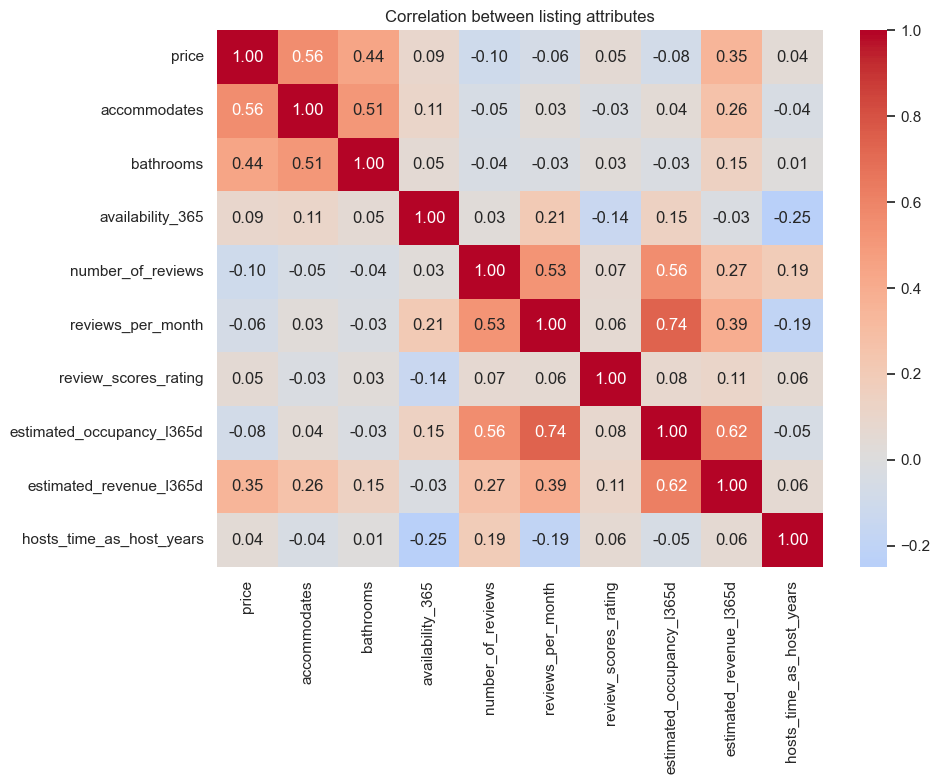

In [4]:
corr_cols = ['price', 'accommodates', 'bathrooms', 'availability_365',
             'number_of_reviews', 'reviews_per_month', 'review_scores_rating',
             'estimated_occupancy_l365d', 'estimated_revenue_l365d',
             'hosts_time_as_host_years']

corr = listings[corr_cols].corr().round(2)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation between listing attributes')
plt.tight_layout()
plt.show()

Chart 1 — price by borough

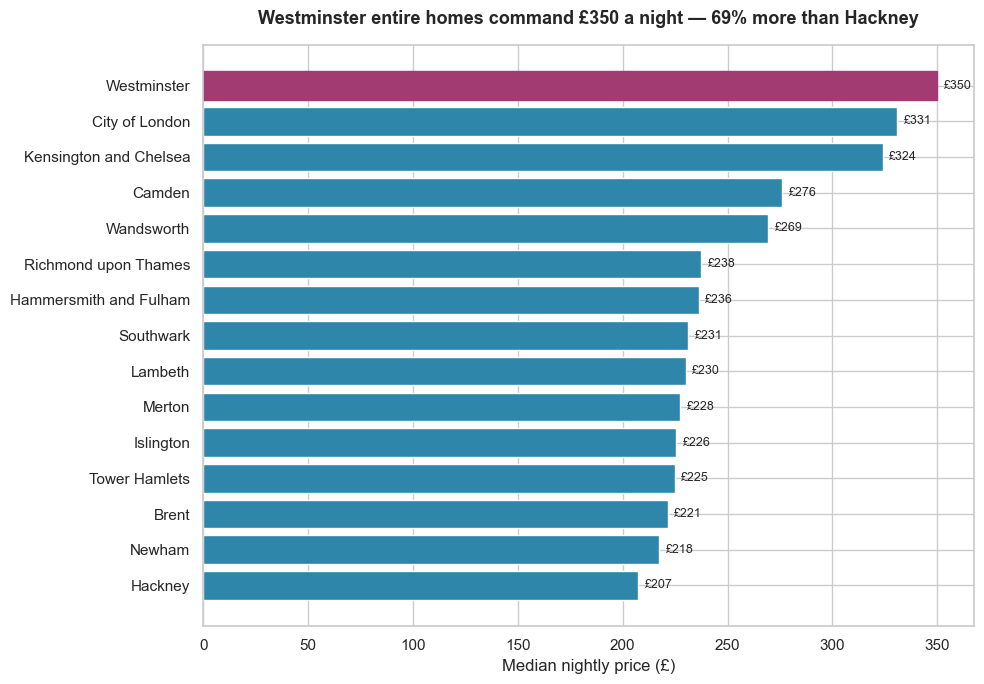

                         median  count
neighbourhood_cleansed                
Westminster             350.000   6892
City of London          331.000    410
Kensington and Chelsea  324.000   4030
Camden                  276.000   3158
Wandsworth              269.330   1925
Richmond upon Thames    237.500    563
Hammersmith and Fulham  236.250   2040
Southwark               231.250   1971
Lambeth                 230.000   1784
Merton                  227.500    667
Islington               225.500   1995
Tower Hamlets           224.775   2602
Brent                   221.335   1256
Newham                  217.500   1099
Hackney                 207.465   2022


In [5]:
borough_price = (listings[listings['room_type'] == 'Entire home/apt']
                 .groupby('neighbourhood_cleansed')['price']
                 .agg(['median', 'count'])
                 .query('count >= 100')
                 .sort_values('median', ascending=False)
                 .head(15))

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(borough_price.index[::-1], borough_price['median'][::-1], color='#2E86AB')
bars[-1].set_color('#A23B72')  # highlight the top borough

ax.set_xlabel('Median nightly price (£)')
ax.set_ylabel('')
ax.set_title('TITLE GOES HERE', fontsize=13, fontweight='bold', pad=15)

for i, v in enumerate(borough_price['median'][::-1]):
    ax.text(v + 3, i, f'£{v:.0f}', va='center', fontsize=9)

ax.set_title('Westminster entire homes command £350 a night — 69% more than Hackney',
             fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

print(borough_price)

**What:** Median nightly prices for entire homes range from £350 in Westminster to £207 in Hackney — a 69% premium for the most expensive borough. The top three (Westminster, City of London, Kensington and Chelsea) are all central; the bottom of the ranking is dominated by outer and east London boroughs.

**So What:** Location alone accounts for a substantial share of pricing power. However, price is not revenue: Westminster's premium only converts into returns if occupancy holds up, and the correlation analysis showed price and estimated revenue are only weakly related (r = 0.35).

**Now What:** Before recommending central boroughs for acquisition, the price ranking must be cross-referenced with occupancy and revenue per available night — analysed in the following charts and the Power BI dashboard.

Chart 2 — superhost comparison

               avg_rating  avg_reviews_pm  avg_occupancy      n
Non-superhost        4.64            0.81            0.0  75003
Superhost            4.86            1.57           83.0  17559


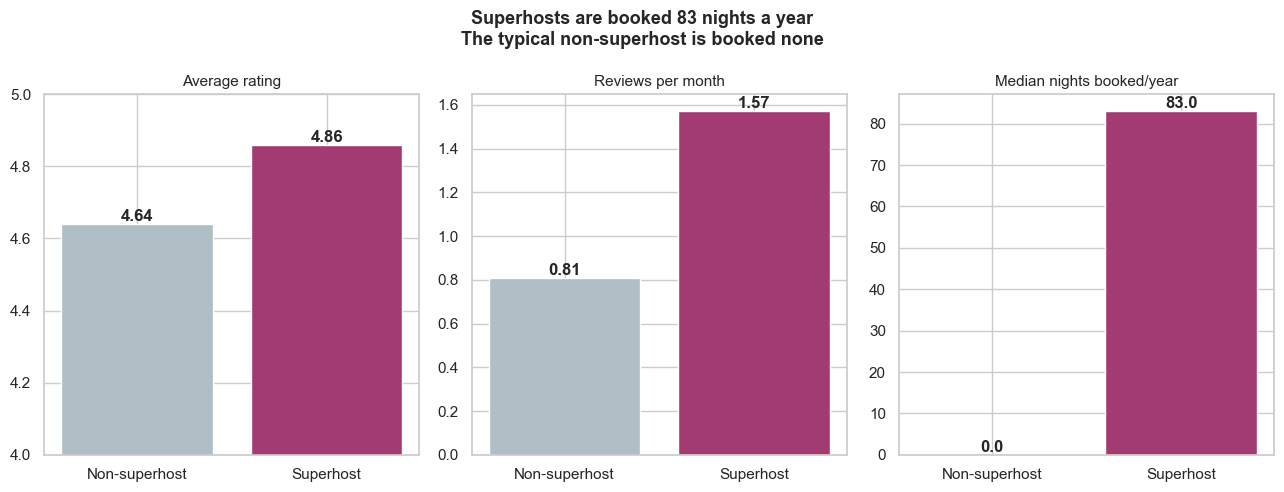

In [6]:
comparison = (listings[listings['host_is_superhost'].notna()]
              .groupby('host_is_superhost')
              .agg(avg_rating=('review_scores_rating', 'mean'),
                   avg_reviews_pm=('reviews_per_month', 'mean'),
                   avg_occupancy=('estimated_occupancy_l365d', 'median'),
                   n=('id', 'count'))
              .round(2))
comparison.index = ['Non-superhost', 'Superhost']
print(comparison)

fig, axes = plt.subplots(1, 3, figsize=(13, 5))
metrics = [('avg_rating', 'Average rating', (4.0, 5.0)),
           ('avg_reviews_pm', 'Reviews per month', None),
           ('avg_occupancy', 'Median nights booked/year', None)]

for ax, (col, label, ylim) in zip(axes, metrics):
    ax.bar(comparison.index, comparison[col], color=['#B0BEC5', '#A23B72'])
    ax.set_title(label, fontsize=11)
    if ylim:
        ax.set_ylim(ylim)
    for i, v in enumerate(comparison[col]):
        ax.text(i, v, f'{v}', ha='center', va='bottom', fontweight='bold')


fig.suptitle('Superhosts are booked 83 nights a year\nThe typical non-superhost is booked none', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**What:** Superhost listings (n=17,559) outperform non-superhosts (n=75,003) on all three measures. The rating gap is modest — 4.86 versus 4.64 — and the rating panel uses a truncated y-axis (4.0–5.0) to make that difference visible. The operational gaps are far larger: superhosts average 1.57 reviews per month against 0.81, and the median superhost listing is booked 83 nights a year while the median non-superhost is booked zero.

**So What:** The difference between superhosts and other hosts is not primarily about guest satisfaction — it is about whether the listing operates as a working business at all. Half of non-superhost listings are effectively dormant. However, this is association rather than causation: superhost status is awarded partly on the basis of booking activity and ratings, so the relationship is partly circular, and superhosts may also own better-located or better-presented properties.

**Now What:** For the Head of Portfolio, this suggests that operational management quality may matter as much as property selection. Phase 6 will test whether superhost status predicts performance once property attributes such as borough, room type and capacity are controlled for, which would separate the effect of management from the effect of the asset itself.

Chart 3 — Revenue concentration

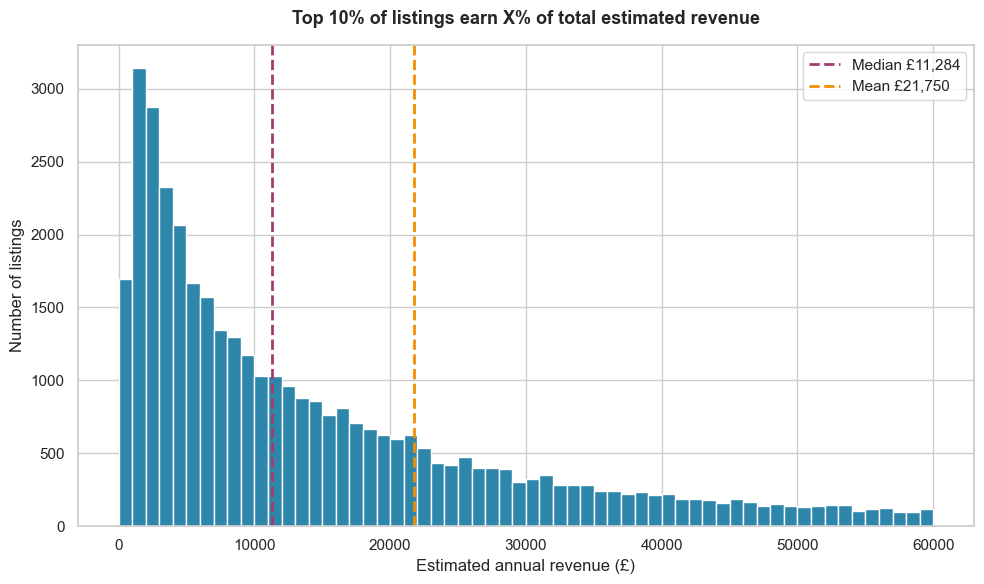

Top 10% of listings earn 43.2% of total estimated revenue


In [7]:
rev = listings['estimated_revenue_l365d'].dropna()
rev = rev[rev > 0]

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(rev, bins=60, range=(0, 60000), color='#2E86AB', edgecolor='white')
ax.axvline(rev.median(), color='#A23B72', linestyle='--', linewidth=2,
           label=f'Median £{rev.median():,.0f}')
ax.axvline(rev.mean(), color='#F18F01', linestyle='--', linewidth=2,
           label=f'Mean £{rev.mean():,.0f}')
ax.set_xlabel('Estimated annual revenue (£)')
ax.set_ylabel('Number of listings')
ax.set_title('Top 10% of listings earn X% of total estimated revenue', fontsize=13, fontweight='bold', pad=15)
ax.legend()
plt.tight_layout()
plt.show()

top10_share = rev.nlargest(int(len(rev)*0.1)).sum() / rev.sum() * 100
print(f"Top 10% of listings earn {top10_share:.1f}% of total estimated revenue")

**What:** Among listings with non-zero estimated revenue, the distribution is heavily right-skewed: median annual revenue is £11,284 while the mean is £21,750, and the top 10% of listings account for 43.2% of total estimated revenue. Note this chart excludes zero-revenue listings; including them (as in the descriptive statistics) lowers the median to £3,920.

**So What:** Airbnb income in London is concentrated in a minority of listings. Market-average revenue figures substantially overstate what a typical property achieves, and would mislead an acquisition business case built on them.

**Now What:** Acquisition modelling should use median revenue for the relevant borough and property type as the base case, not the market average, and should identify what distinguishes the top-decile listings — the focus of the machine learning phase.

Chart 4 — Reviews over time

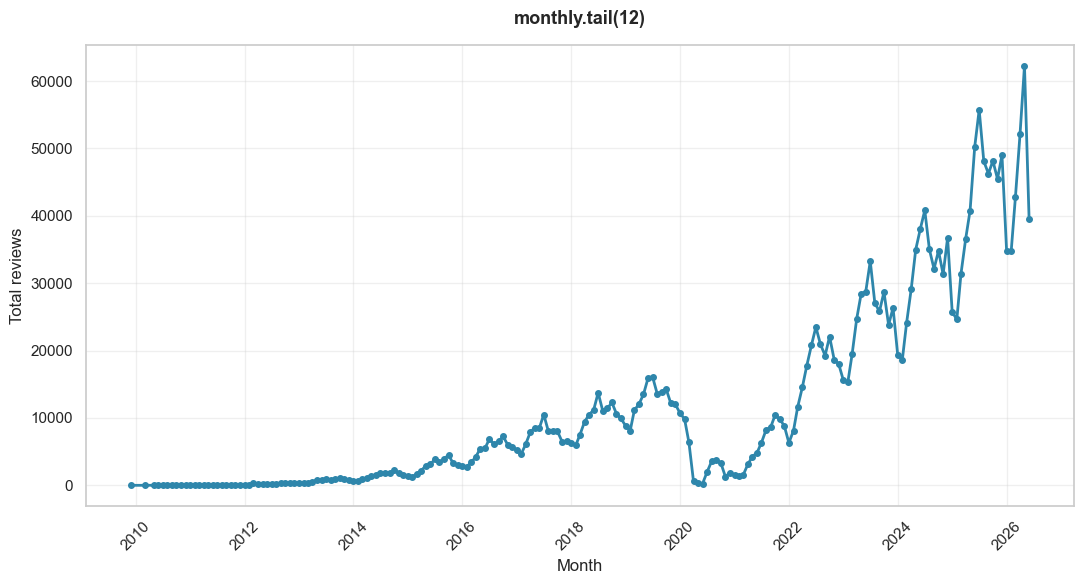

    year_month  review_count
184 2025-07-01         55725
185 2025-08-01         48093
186 2025-09-01         46261
187 2025-10-01         48148
188 2025-11-01         45473
189 2025-12-01         49004
190 2026-01-01         34828
191 2026-02-01         34794
192 2026-03-01         42717
193 2026-04-01         52075
194 2026-05-01         62256
195 2026-06-01         39481


In [8]:
rm = reviews_monthly.copy()
rm['year_month'] = pd.to_datetime(rm['year_month'])
monthly = rm.groupby('year_month')['review_count'].sum().reset_index()

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(monthly['year_month'], monthly['review_count'],
        color='#2E86AB', linewidth=2, marker='o', markersize=4)
ax.set_xlabel('Month')
ax.set_ylabel('Total reviews')
ax.set_title('monthly.tail(12)', fontsize=13, fontweight='bold', pad=15)
ax.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(monthly.tail(12))

**What:** Monthly review volume grew steadily from 2010, collapsed in 2020 during COVID-19 travel restrictions, and recovered strongly from 2021 onward to reach new highs above 55,000 reviews per month in mid-2025. A consistent seasonal pattern is visible: volumes peak in summer (July 2025: 55,725) and fall in winter (January 2026: 34,828, February 2026: 34,794) — roughly a 37% swing.

**So What:** Demand for London short-lets is both growing and strongly seasonal. For the Head of Portfolio, this means annual revenue figures conceal significant within-year variation, and cash-flow planning must account for a weak winter period.

**Now What:** Seasonality should be modelled explicitly in the Power BI dashboard using time intelligence measures, so that acquisition scenarios are stress-tested against winter troughs rather than annual averages. The final data point should be checked for partial-month effects given the June 2026 scrape date.

In [9]:
import os
os.makedirs('../charts', exist_ok=True)
print("Charts folder ready")

Charts folder ready


In [10]:
fig.savefig('../charts/chart1_price_by_borough.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
fig.savefig('../charts/chart2_superhost_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
fig.savefig('../charts/chart3_revenue_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
fig.savefig('../charts/chart4_reviews_trend.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
print(os.listdir('../charts'))

['chart1_price_by_borough.png', 'chart2_superhost_comparison.png', 'chart3_revenue_distribution.png', 'chart4_reviews_trend.png']
